# 1.5 — Hubs and basis

> *"In theory, there is no difference between theory and practice. In practice, there is."*
> — attributed to Yogi Berra; also an accurate description of the TTF–PEG spread in 2022.

## The problem

The risk we inherit is often **PEG** (French hub) while the liquidity is in **TTF** (Dutch hub). Chapter
1.3 told us to hedge the liquid proxy; Chapter 1.4 told us that proxy hedging leaves $(1-\rho^2)$ of the
variance behind. So the questions are:

1. How closely do the hubs move together, and **why**?
2. What does the *basis* (PEG − TTF) look like as a process — noise, trend, or something that snaps back?
3. When does the relationship break, and what does that do to a hedge?

This chapter also completes the vocabulary of Module 1: after it, every exposure in the book can be
described as a *tenor × hub* cell with a volatility, a correlation to the liquid benchmark, and a
liquidity estimate.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_hub_history
from gashedge.hedging import ols, min_variance_hedge_ratio, hedge_effectiveness
from gashedge.plotting import plot_series
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch1.5")
log.info("Environment ready")

2026-09-13 16:46:56.823 | INFO    | ch1.5 | Environment ready


## 1. The European hub map in one paragraph

Gas is traded at *virtual trading points* within entry–exit zones: **TTF** (Netherlands), **THE**
(Germany), **PEG** (France), **PSV** (Italy), **ZTP** (Belgium), **NBP** (UK, priced in pence/therm).
They are connected by pipelines with finite capacity and by shared LNG supply. When capacity is ample,
arbitrage keeps prices within transport cost of each other — the **basis** is small and mean-reverting.
When capacity binds (a pipeline is full, an interconnector is down, an LNG terminal is saturated), the
hubs *decouple* and the basis can move by tens of euros.

Two real episodes worth remembering:

* **Summer 2022, NBP vs TTF.** The UK's LNG terminals were importing far more than the UK could use or
  export through the two interconnectors to the continent. NBP traded at a **discount of tens of
  EUR/MWh** to TTF for weeks — a hedger short TTF against long NBP lost on both legs.
* **Autumn 2022, PEG vs TTF.** France, with four LNG terminals and full storage, saw PEG trade at a
  persistent *discount* to TTF while the German/Dutch system was scrambling to replace Russian pipeline
  gas. The "usual" PEG premium (transport cost from TTF to France) flipped sign.

Our simulator reproduces these qualitative features: a small positive PEG premium that mean-reverts,
a noisier NBP basis, and a `crisis=True` mode where the basis blows out.

2026-09-13 16:46:56.834 | INFO    | gashedge.market_data | Simulated 1000 days of hub history (crisis=False); TTF range 21.7-59.9


2026-09-13 16:46:56.841 | INFO    | gashedge.market_data | Simulated 1000 days of hub history (crisis=True); TTF range 17.9-379.6


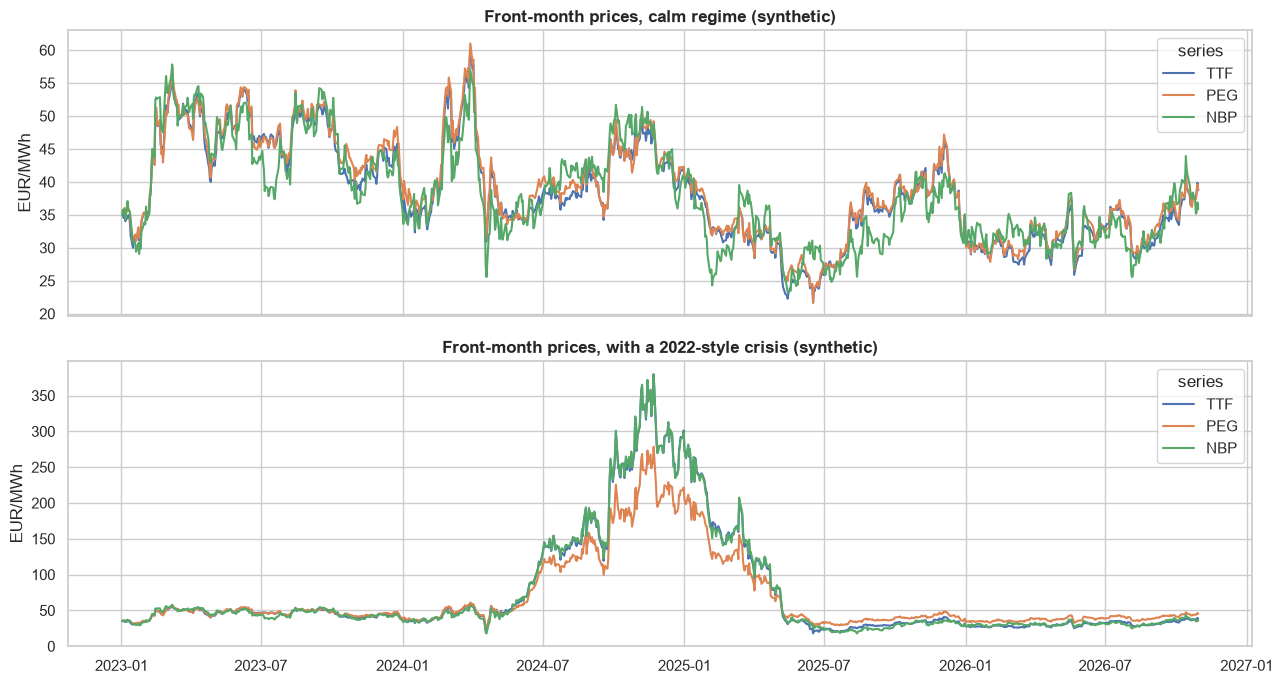

In [2]:
calm = simulate_hub_history(n_days=1000, crisis=False)
crisis = simulate_hub_history(n_days=1000, crisis=True)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
plot_series(calm, title="Front-month prices, calm regime (synthetic)", ax=axes[0])
plot_series(crisis, title="Front-month prices, with a 2022-style crisis (synthetic)", ax=axes[1])
plt.tight_layout()

## 2. The basis as a process

Define the basis $b_t = S_t - F_t$ (PEG minus TTF). If the two hubs are linked by arbitrage, $b_t$ should
hover around the transport cost and be pulled back when it strays. The simplest model with that property
is the discrete **Ornstein–Uhlenbeck** (AR(1)) process:

$$
b_{t+1} - b_t = \kappa\,(\mu - b_t) + \eta_{t+1}
\tag{1.13}
$$

$\kappa$ is the speed of mean reversion, $\mu$ the long-run basis. We can *estimate* both by regressing
$\Delta b_t$ on $b_t$: the slope is $-\kappa$ and the intercept is $\kappa\mu$. The **half-life** — how
long a shock takes to decay by half — is

$$
t_{1/2} = \frac{\ln 2}{\kappa}
\tag{1.14}
$$

2026-09-13 16:46:57.074 | INFO    | ch1.5 | OU fit (calm): kappa=0.108 (se 0.014), mu=0.73 EUR/MWh, half-life=6.4 days


kappa             0.108
mu                0.728
half_life_days    6.411
resid_std         0.372
kappa_se          0.014
dtype: float64

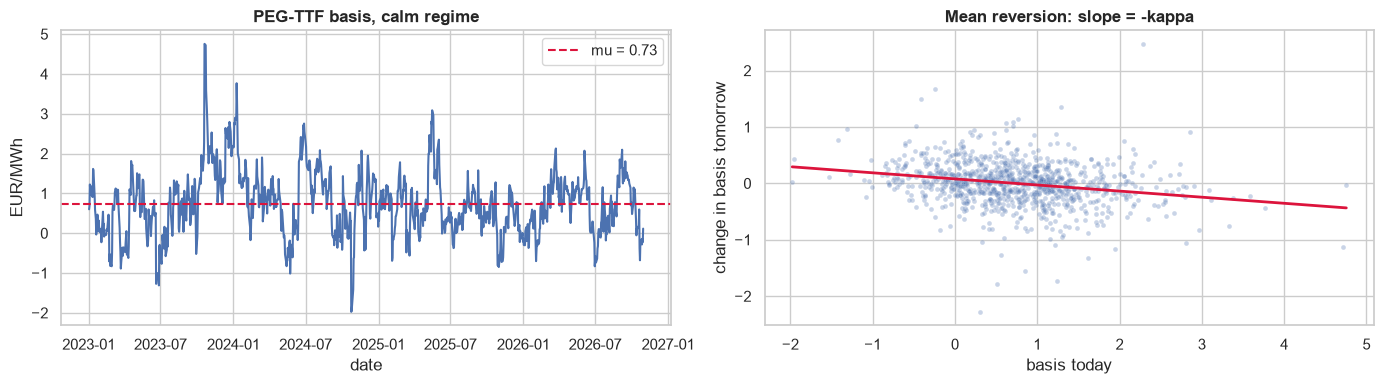

In [3]:
def fit_ou(basis: pd.Series) -> dict:
    b = basis.dropna()
    fit = ols(b.diff().dropna().values, b.shift(1).dropna().values, names=["b_lag"])
    kappa = -fit.beta[1]
    mu = fit.beta[0] / kappa
    return {"kappa": kappa, "mu": mu, "half_life_days": np.log(2) / kappa, "resid_std": fit.resid.std(ddof=2),
            "kappa_se": fit.se[1]}

basis_calm = (calm.PEG - calm.TTF).rename("PEG-TTF basis")
ou = fit_ou(basis_calm)
log.info("OU fit (calm): kappa=%.3f (se %.3f), mu=%.2f EUR/MWh, half-life=%.1f days", ou["kappa"], ou["kappa_se"], ou["mu"], ou["half_life_days"])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(x=basis_calm.index, y=basis_calm.values, ax=axes[0]); axes[0].axhline(ou["mu"], color="crimson", ls="--", label=f"mu = {ou['mu']:.2f}")
axes[0].set_title("PEG-TTF basis, calm regime"); axes[0].legend(); axes[0].set_ylabel("EUR/MWh")
sns.scatterplot(x=basis_calm.shift(1).values, y=basis_calm.diff().values, alpha=0.3, s=12, ax=axes[1])
grid = np.linspace(basis_calm.min(), basis_calm.max(), 20)
axes[1].plot(grid, ou["kappa"] * (ou["mu"] - grid), color="crimson", lw=2)
axes[1].set_xlabel("basis today"); axes[1].set_ylabel("change in basis tomorrow"); axes[1].set_title("Mean reversion: slope = -kappa")
plt.tight_layout()
pd.Series(ou).round(3)

A half-life of about a week or two is typical of well-connected hubs in normal times. The practical
reading: **a basis shock is a temporary P&L swing, not a permanent loss** — *if* you can hold the position
through it. That "if" is margin and risk-limit management (Chapter 2.2).

## 3. Variance decomposition: what a TTF hedge does for PEG risk

If we hold $Q$ MWh of PEG and sell $Q$ MWh of TTF (a 1:1 hedge), the daily P&L is
$Q(\Delta S - \Delta F) = Q\,\Delta b$. So

$$
\text{Var}(\Delta S) = \text{Var}(\Delta F) + \text{Var}(\Delta b) + 2\,\text{Cov}(\Delta F, \Delta b)
\tag{1.15}
$$

and the 1:1 hedge leaves exactly $\text{Var}(\Delta b)$. Hedge *effectiveness* is the fraction removed:

$$
E_{1:1} = 1 - \frac{\text{Var}(\Delta b)}{\text{Var}(\Delta S)}
\tag{1.16}
$$

In [4]:
def decompose(df: pd.DataFrame, label: str) -> dict:
    dS, dF = df.PEG.diff().dropna(), df.TTF.diff().dropna()
    db = dS - dF
    h = min_variance_hedge_ratio(dS, dF)
    return {"regime": label, "std_dPEG": dS.std(), "std_dTTF": dF.std(), "std_dbasis": db.std(),
            "2cov_dTTF_dbasis": 2 * dF.cov(db), "eff_1to1": hedge_effectiveness(dS, dF, 1.0),
            "h_star": h, "eff_hstar": hedge_effectiveness(dS, dF, h), "corr": dS.corr(dF),
            "residual_eur_per_day_10k_mwh": 10_000 * db.std()}

decomp = pd.DataFrame([decompose(calm, "calm"), decompose(crisis, "crisis")]).set_index("regime")
log.info("1:1 TTF hedge removes %.1f%% of PEG variance in calm, %.1f%% in crisis; residual std %.2f vs %.2f EUR/MWh",
         100 * decomp.eff_1to1["calm"], 100 * decomp.eff_1to1["crisis"], decomp.std_dbasis["calm"], decomp.std_dbasis["crisis"])
decomp.round(3)

2026-09-13 16:46:57.234 | INFO    | ch1.5 | 1:1 TTF hedge removes 92.1% of PEG variance in calm, 78.1% in crisis; residual std 0.38 vs 2.65 EUR/MWh


,std_dPEG,std_dTTF,std_dbasis,2cov_dTTF_dbasis,eff_1to1,h_star,eff_hstar,corr,residual_eur_per_day_10k_mwh
regime,,,,,,,,,
calm,1.361,1.309,0.382,-0.007,0.921,0.998,0.921,0.960,3822.785
crisis,5.661,7.820,2.647,-36.109,0.781,0.705,0.948,0.974,26466.226


In the calm regime the TTF hedge removes the overwhelming majority of PEG variance; the basis is a small
residual and the optimal ratio $h^*$ is indistinguishable from 1. Now read the crisis row:

* **Effectiveness falls** — the basis stops being a quiet nuisance and becomes a driver of its own.
* **The optimal ratio drops well below 1.** In the simulated crisis PEG *under-reacts* to TTF (a French
  system long LNG regas capacity does not feel continental scarcity one-for-one — the 2022 pattern). A
  desk still hedging 1:1 is now *over-hedged* by ~30 %: it has a net short TTF position it never chose.
* **The absolute residual explodes.** Even with the best ratio, the daily P&L noise left after hedging is
  many times the calm-regime number in euros — and that, not the $R^2$, is what breaches limits and
  triggers margin calls.

Two dashboards are therefore needed: a *relative* one (effectiveness, correlation) to tell you the
relationship is changing, and an *absolute* one (residual EUR/day, Chapter 3.4) to tell you whether you
can afford it. How to re-estimate $h^*$ when the regime shifts under you is Chapter 3.5.

## 4. Rolling correlation: the picture a risk manager watches

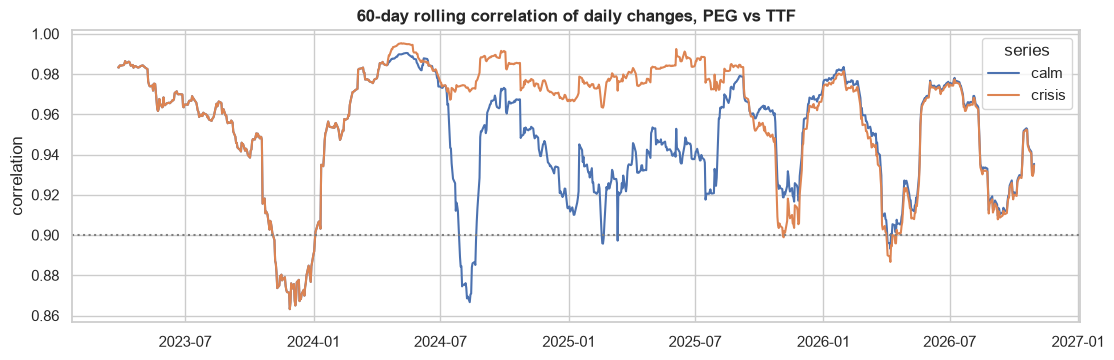

In [5]:
window = 60
roll_corr = pd.DataFrame({
    "calm": calm.PEG.diff().rolling(window).corr(calm.TTF.diff()),
    "crisis": crisis.PEG.diff().rolling(window).corr(crisis.TTF.diff()),
})
fig, ax = plt.subplots(figsize=(13, 3.8))
plot_series(roll_corr, title=f"{window}-day rolling correlation of daily changes, PEG vs TTF", ylabel="correlation", ax=ax)
ax.axhline(0.9, color="0.5", ls=":");

## 5. Basis in *levels* vs *changes* — a trap to avoid now

You will be tempted to regress PEG **prices** on TTF **prices** and read off a beautiful $R^2$ of 0.99.
Do not. Two random walks that share a trend look correlated in levels even when their daily changes are
unrelated (*spurious regression*, Granger & Newbold 1974). Hedging is about **changes** — what happens to
P&L tomorrow — so every statistic in this tutorial is computed on $\Delta$'s. (The one legitimate use of
levels is *cointegration*: testing whether the basis itself is stationary, which is what the OU fit above
does in a simple way.)

In [6]:
lvl = ols(calm.PEG.values, calm.TTF.values, names=["TTF_level"])
chg = ols(calm.PEG.diff().dropna().values, calm.TTF.diff().dropna().values, names=["dTTF"])
log.info("R2 on levels = %.4f; R2 on changes = %.4f. Only the second one is about tomorrow's P&L.", lvl.r2, chg.r2)
pd.DataFrame({"levels": lvl.summary().coef, "changes": chg.summary().coef}).round(3)

2026-09-13 16:46:57.342 | INFO    | ch1.5 | R2 on levels = 0.9880; R2 on changes = 0.9211. Only the second one is about tomorrow's P&L.


,levels,changes
TTF_level,0.992,NaN
const,1.029,-0.000
dTTF,NaN,0.998


## 6. Module 1 in one table

Every exposure the market-making books hand us can now be placed in a grid:

| dimension | what we learned | where |
|---|---|---|
| **contract** | symbol, hours, lot, tick, expiry | 1.1 |
| **tenor** | strips decompose exactly into months; storage caps seasonal spreads | 1.2 |
| **liquidity** | front & near strips liquid; cost ∝ half-spread + √size; think in days | 1.3 |
| **dynamics** | vol decays with tenor; correlation decays with distance; ratio = ρσ_S/σ_F | 1.4 |
| **hub** | basis mean-reverts (half-life ~days) until capacity binds; hedge on changes, not levels | 1.5 |

**Pitfall that leads to Module 2:** we know *what* the risk is and *where* it can be traded. We have
not yet said what a hedge is *for*. "Minimise variance" is a convenient answer but it is not free —
every hedge costs spread, margin and roll. Module 2 starts by asking what "good" means for a hedger who
is paid to *carry* other people's residual risk.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** An OU fit gives $\kappa = 0.08$ per day. What is the half-life of a basis shock? If the basis today is 3.00 above its mean, what is its expected level in 10 days (ignoring noise)?

<details><summary><i>Answer 1</i></summary>

Half-life $= \ln 2 / 0.08 = \mathbf{8.66}$ days. Expected deviation after $n$ days is $(1-\kappa)^n \times 3.00 = 0.92^{10}\times 3.00 = 0.434 \times 3.00 = \mathbf{1.30}$ above the mean (continuous-time approximation $3e^{-0.8} = 1.35$ is close). Roughly: after ~9 days half the shock has gone, after ~18 days three-quarters.

</details>

**Q2.** Daily changes: $\sigma_{\Delta \text{TTF}} = 1.20$, $\sigma_{\Delta b} = 0.35$ EUR/MWh, and $\text{Cov}(\Delta F, \Delta b) = 0$. What is the effectiveness of a 1:1 TTF hedge for PEG? What if, in a crisis, $\sigma_{\Delta b}$ triples while $\sigma_{\Delta \text{TTF}}$ doubles?

<details><summary><i>Answer 2</i></summary>

Calm: $\text{Var}(\Delta S) = 1.44 + 0.1225 = 1.5625$; $E = 1 - 0.1225/1.5625 = \mathbf{92.2\%}$. Crisis: $\text{Var}(\Delta F) = 5.76$, $\text{Var}(\Delta b) = 1.1025$, $\text{Var}(\Delta S) = 6.8625$; $E = 1 - 1.1025/6.8625 = \mathbf{83.9\%}$. Effectiveness falls because the residual grew faster than the total. (It can also go the other way if the hedge instrument's variance explodes faster than the basis — which is why the ratio alone is a poor crisis dashboard.) What is unambiguous is the *absolute* residual std: from 0.35 to 1.05 EUR/MWh, three times the daily P&L noise on the same position, which is what hits limits and margin.

</details>

**Q3.** Why would regressing PEG *prices* on TTF *prices* give a misleadingly high $R^2$, and what single change to the data fixes it?

<details><summary><i>Answer 3</i></summary>

Both series are (near) random walks sharing a common stochastic trend; their levels wander together regardless of whether their *innovations* are related, so the level regression inherits a spuriously high $R^2$ and badly biased standard errors (Granger–Newbold). Regress **first differences** ($\Delta$PEG on $\Delta$TTF) — that measures co-movement of daily P&L, which is what a hedge must offset. (If you specifically want to know whether the *spread* is stable, test the basis for stationarity instead — that is cointegration, and it is the right tool for deciding whether a basis shock is temporary.)

</details>

**Q4.** In summer 2022 NBP traded at a large discount to TTF. A UK desk was long NBP and hedged 1:1 short TTF. Describe the P&L mechanics day by day as the discount widened, and what the OU model would have said about the trade — and why that was cold comfort.

<details><summary><i>Answer 4</i></summary>

Each day the discount widened by $x$, the long NBP leg lost more (or gained less) than the short TTF leg gained (or lost): daily P&L $= Q\,\Delta b$, with $\Delta b < 0$ persistently. The OU model says the basis will *revert* — the expected future P&L is positive — but (i) the regime had changed (the interconnectors were physically full, so the arbitrage that drives reversion was *switched off* — κ collapsed toward zero), and (ii) the losses were **realised daily through variation margin** on the TTF futures while the NBP leg was, if OTC or physical, not paying cash. A correct long-run model does not help if the path exhausts your liquidity or your limits first — the Metallgesellschaft lesson of Chapter 2.4.

</details>


---
◀ [Previous](04_curve_dynamics.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](../module2_hedging_core/01_why_hedge.ipynb)